In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

import jax

jax.config.update("jax_enable_x64", True)
# Set the default device to CPU
jax.config.update("jax_default_device", jax.devices("cpu")[0])
import jax.numpy as jnp

from tensorrsvd import ho_rsvd

from optimization_core import (
    build_jsa_grid,
    scaled_spdc_jsa_vectorized,
    scaled_spdc_jsa_vectorized_rsvd,
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# Dispersion parameters
ldelk01 = 0  # Phase mismatch at the central frequencies
tau11 = 0  # Group-velocity matching
taup = 7.5  # \beta_P << \beta_F -->\beta_P negligible in comparison to \beta_F
tauf1 = 1.5  # \beta_F >> \beta_P
T0 = tauf1 / jnp.sqrt(jnp.pi)  # Pump bandwidth


# Geometrical parameters
n_res = 30  # Number of points inside the bandwidth of the phase-matching function in the frequency grid nxnxn
d = 3  # Dimensionality of the problem

# Spectral resolution
sigmapm = (
    jnp.sqrt(jnp.pi) / tauf1
)  # Approximate HWHM of the phase-matching function, measured in terms of the sinc's main lobe width
delw = (
    sigmapm / n_res
)  # The spectral resolution is defined such that a minimum of n discrete points are sampled within each frequency vector over the bandwidth of the phase-matching function, regardless of the specific width of the evaluation function.

# Spectral window
domg = (
    4 * sigmapm
)  # We set the half-width of the frequency window wide enough to sample correctly both the jsa and reduced density matrix
n = int(jnp.ceil(2 * domg / delw)) + 1  # +1 so linspace's actual spacing is <= delw
print(
    n
)  # Note: Always check the frequency vector size, because later we are going to build a 3D grid with it, which greatly affects  the memory usage.
omf = jnp.linspace(-domg, domg, n)

# omf=jnp.arange(-domg,domg,delw)
# n=omf.size
# print(n) # Note: Always check the frequency vector size, because later we are going to build a 3D grid with it, which greatly affects  the memory usage.


# Create N‑dimensional meshgrid
grid = jnp.meshgrid(*([omf] * d), indexing="ij")
# points= jnp.stack([g.ravel() for g in grid], axis=1)

241


In [3]:
# ---------------------------------------------------------
# 2. Build JSA grid and initial mode
# ---------------------------------------------------------
jsa = scaled_spdc_jsa_vectorized(
    ldelk0=ldelk01, tau1=tau11, taup=taup, tauf=tauf1, T0=T0
)  # Returns a callable function that evaluates the JSA on a point or a grid.
jsa_data = jsa(
    *grid
)  # Evaluate the JSA on the grid. This is the most memory intensive step, as it creates a large tensor of size (n,n,n) in this case. Always check the size of the grid and the resulting tensor to avoid memory issues.
jsa_norm = jnp.linalg.norm(jsa_data)

jsa_flat = jnp.reshape(jsa_data, (n, n ** (d - 1)))
u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)

In [4]:
f = scaled_spdc_jsa_vectorized_rsvd(
    ldelk0=ldelk01, tau1=tau11, taup=taup, tauf=tauf1, domg=domg, T0=T0
)  # Returns a callable function that evaluates the JSA on a point or a grid.

In [5]:
rank = 30
U_list, S_list = ho_rsvd(
    tensor=f,
    tensor_shape=(n,) * d,
    dtype=jnp.float64,
    rank=rank,
    num_oversamples=10,
    num_power_iterations=2,
    num_idxs=d,
    backend="jax",
)

In [6]:
s_norm = s / jnp.linalg.norm(s)
S_list_norm = S_list[0] / jsa_norm

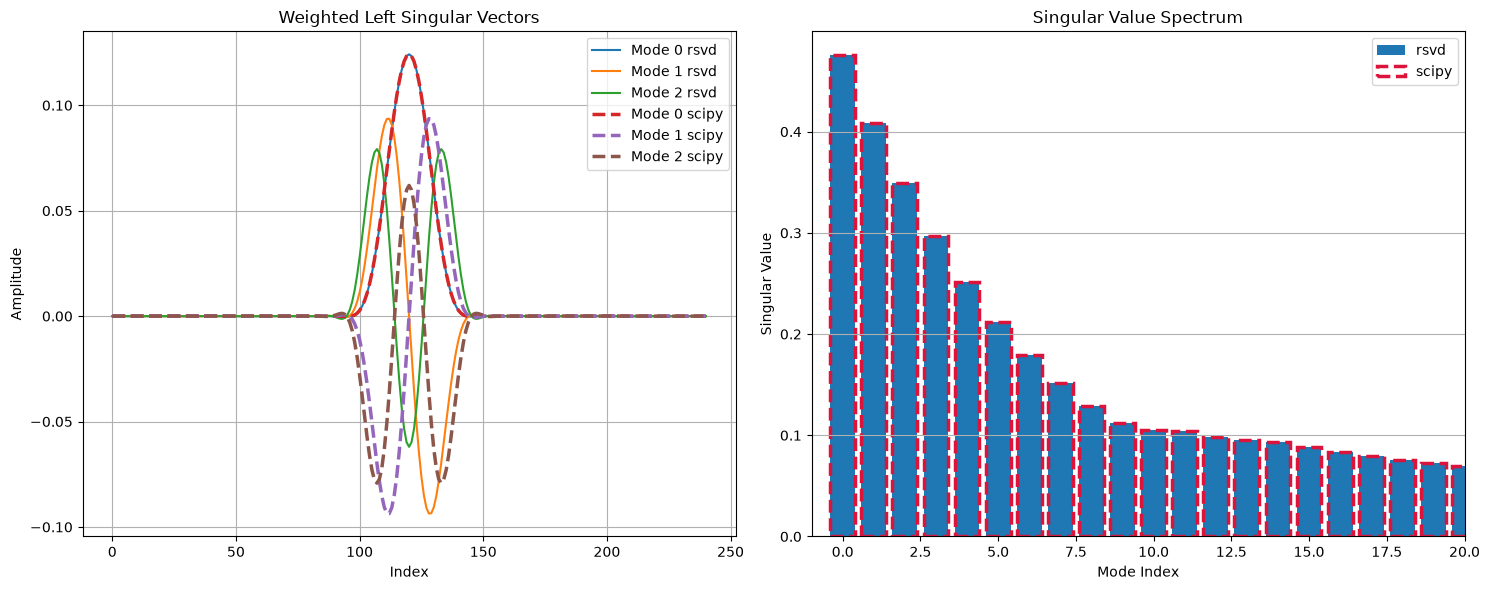

In [7]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

n_modes = 3  # Number of modes to plot
for i in range(n_modes):
    axes[0].plot(S_list_norm[i] * U_list[0][:, i], label=f"Mode {i} rsvd")
for i in range(n_modes):
    axes[0].plot(
        -1 * s_norm[i] * u[:, i], label=f"Mode {i} scipy", linestyle="--", linewidth=2.5
    )

axes[0].set_xlabel("Index")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Weighted Left Singular Vectors")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Singular values (Scree plot)
axes[1].bar(jnp.arange(len(S_list[0])), S_list_norm, label="rsvd")
axes[1].bar(
    jnp.arange(len(s)),
    s_norm,
    label="scipy",
    linestyle="--",
    linewidth=2.5,
    color="none",
    edgecolor="crimson",
)
axes[1].set_xlim(-1, 20)
axes[1].set_xlabel("Mode Index")
axes[1].set_ylabel("Singular Value")
axes[1].set_title("Singular Value Spectrum")
axes[1].legend()
axes[1].grid(axis="y")

plt.tight_layout()  # Prevents overlapping labels
plt.show()

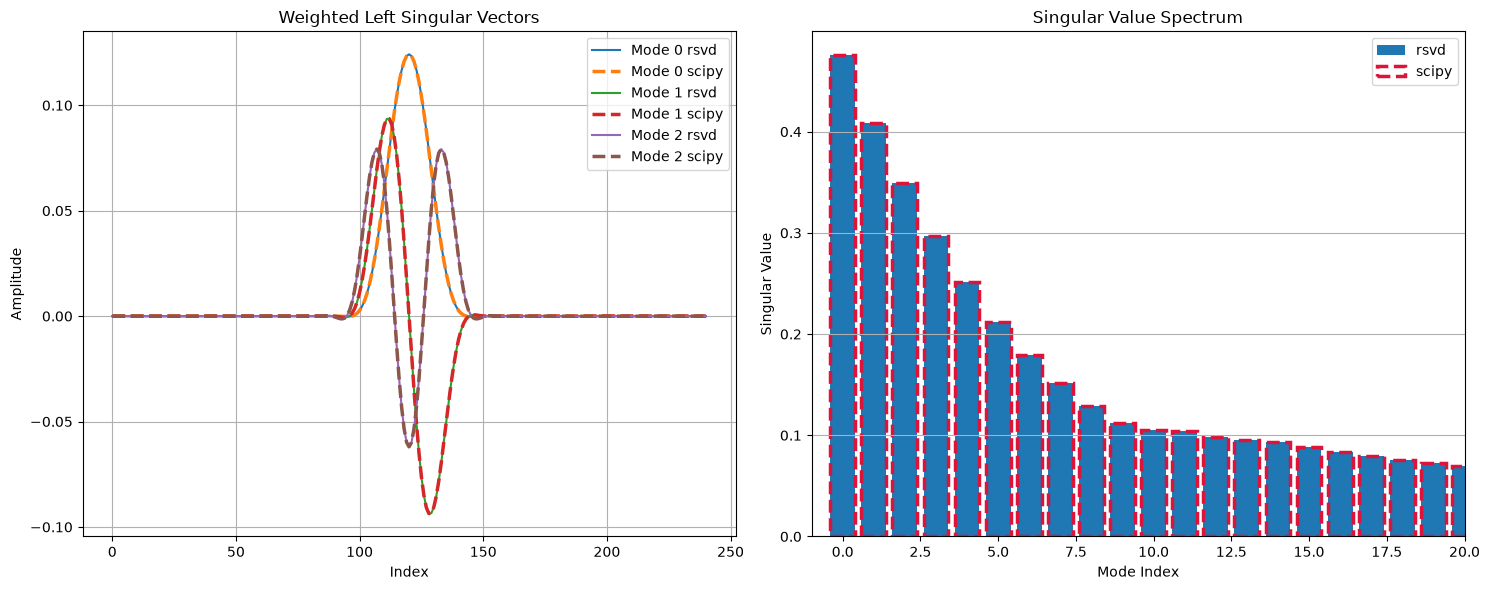

In [8]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

n_modes = 1  # Number of modes to plot
axes[0].plot(S_list_norm[0] * U_list[0][:, 0], label=f"Mode {0} rsvd")
axes[0].plot(
    -1 * s_norm[0] * u[:, 0], label=f"Mode {0} scipy", linestyle="--", linewidth=2.5
)
axes[0].plot(S_list_norm[1] * U_list[0][:, 1], label=f"Mode {1} rsvd")
axes[0].plot(
    s_norm[1] * u[:, 1], label=f"Mode {1} scipy", linestyle="--", linewidth=2.5
)
axes[0].plot(S_list_norm[2] * U_list[0][:, 2], label=f"Mode {2} rsvd")
axes[0].plot(
    s_norm[2] * u[:, 2], label=f"Mode {2} scipy", linestyle="--", linewidth=2.5
)

axes[0].set_xlabel("Index")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Weighted Left Singular Vectors")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Singular values (Scree plot)
axes[1].bar(jnp.arange(len(S_list[0])), S_list_norm, label="rsvd")
axes[1].bar(
    jnp.arange(len(s)),
    s_norm,
    label="scipy",
    linestyle="--",
    linewidth=2.5,
    color="none",
    edgecolor="crimson",
)
axes[1].set_xlim(-1, 20)
axes[1].set_xlabel("Mode Index")
axes[1].set_ylabel("Singular Value")
axes[1].set_title("Singular Value Spectrum")
axes[1].grid(axis="y")
axes[1].legend()

plt.tight_layout()  # Prevents overlapping labels
plt.show()

In [9]:
def plot_2d_projection(jsa_vals):
    """
    Plot a 2D projection of a multivariate PDF f by varying two coordinates
    and fixing the rest at their mean values.

    f: vectorized PDF function created by make_mvn_pdf_vectorized
    mean: (d,) array
    idx: tuple (i,j) selecting which coordinates to vary
    n: grid resolution
    lim: plot range [-lim, lim]
    """
    d = jnp.ndim(jsa_vals)

    jsa_vals /= jnp.linalg.norm(jsa_vals)

    # Square the JSA
    jsa_sq = jsa_vals**2

    # Sum over axes 2..d-1
    axes_to_sum = tuple(range(2, d))
    S = jnp.sum(jsa_sq, axis=axes_to_sum)

    plt.figure(figsize=(6, 5))

    plt.imshow(S, origin="lower", cmap="viridis", alpha=0.85)
    # plt.contour(axis, axis, S, colors="white", linewidths=0.7)

    plt.colorbar(label="Intensity")
    plt.xlabel(r"i")
    plt.ylabel(r"j")
    plt.title("2D Projection of Joint spectral intensity")

    plt.show()

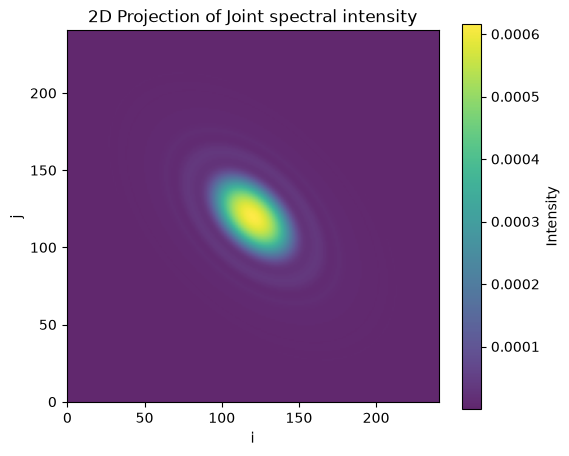

In [10]:
plot_2d_projection(jsa_data)

In [11]:
axis01 = jnp.linspace(0, 1, n)
grid01 = jnp.meshgrid(*([axis01] * d), indexing="ij")

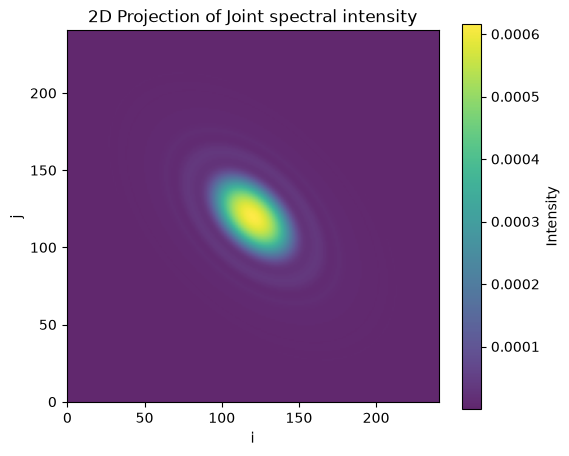

In [12]:
plot_2d_projection(f(*grid01))

In [13]:
diff = jsa_data / jnp.linalg.norm(jsa_data) - f(*grid01) / jnp.linalg.norm(f(*grid01))
print("max abs diff:", jnp.max(jnp.abs(diff)))
print("dtype jsa:", jsa_data.dtype, " dtype f:", f(*grid01).dtype)

max abs diff: 5.2475385148298415e-17
dtype jsa: float64  dtype f: float64
